1.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dataset = pd.read_csv('https://raw.githubusercontent.com/leonkag/Statistics0/main/HELPrct.csv')
print(dataset.head(5), end='\n\n')

print("Dataset Shape:\n", dataset.shape,"\n\n")
print("\nDataset Description:\n",dataset.describe(),"\n\n")

   Unnamed: 0  age  anysubstatus anysub  cesd  d1  daysanysub  dayslink  \
0           1   37           1.0    yes    49   3       177.0     225.0   
1           2   37           1.0    yes    30  22         2.0       NaN   
2           3   26           1.0    yes    39   0         3.0     365.0   
3           4   39           1.0    yes    15   2       189.0     343.0   
4           5   32           1.0    yes    39  12         2.0      57.0   

   drugrisk  e2b  ...        pcs pss_fr racegrp satreat  sexrisk  substance  \
0       0.0  NaN  ...  58.413689      0   black      no        4    cocaine   
1       0.0  NaN  ...  36.036942      1   white      no        7    alcohol   
2      20.0  NaN  ...  74.806328     13   black      no        2     heroin   
3       0.0  1.0  ...  61.931679     11   white     yes        4     heroin   
4       0.0  1.0  ...  37.345585     10   black      no        6    cocaine   

   treat  avg_drinks  max_drinks hospitalizations  
0    yes          13  

2.

In [21]:
for i in dataset.select_dtypes(include=['object', 'category']):
    print(f"\n{'='*60}")
    print(f"Frequency Table for: {i}")
    print('='*60)

    f = dataset[i].value_counts(dropna=False, normalize=False).to_frame('Count')
    f['Proportion'] = dataset[i].value_counts(normalize=True, dropna=False)
    f['Percentage'] = f['Proportion'] * 100

    print(f)



Frequency Table for: anysub
        Count  Proportion  Percentage
anysub                               
NaN       207    0.456954   45.695364
yes       190    0.419426   41.942605
no         56    0.123620   12.362031

Frequency Table for: sex
        Count  Proportion  Percentage
sex                                  
male      346    0.763797   76.379691
female    107    0.236203   23.620309

Frequency Table for: g1b
     Count  Proportion  Percentage
g1b                               
no     326    0.719647    71.96468
yes    127    0.280353    28.03532

Frequency Table for: homeless
          Count  Proportion  Percentage
homeless                               
housed      244    0.538631   53.863135
homeless    209    0.461369   46.136865

Frequency Table for: link
      Count  Proportion  Percentage
link                               
no      268    0.591611   59.161148
yes     163    0.359823   35.982340
NaN      22    0.048565    4.856512

Frequency Table for: racegrp
         

3.

In [22]:
subset = dataset[dataset['anysub'] == 'yes']
counts = subset['sex'].value_counts()
print(counts, end="\n\n")


sex
male      150
female     40
Name: count, dtype: int64



4

substance
cocaine    84
alcohol    75
heroin     66
Name: count, dtype: int64



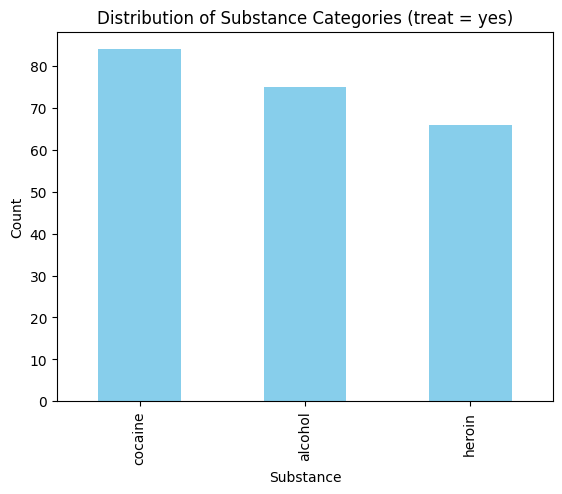

In [30]:
subset = dataset[dataset['treat'] == 'yes']
subset_count = subset['substance'].value_counts()
print(subset_count, end="\n\n")
subset_count.plot(kind='bar', color='skyblue')
plt.title('Distribution of Substance Categories (treat = yes)')
plt.xlabel('Substance')
plt.ylabel('Count')
plt.show()


5

substance
cocaine    84
alcohol    75
heroin     66
Name: count, dtype: int64

substance
cocaine    37.333333
alcohol    33.333333
heroin     29.333333
Name: proportion, dtype: float64



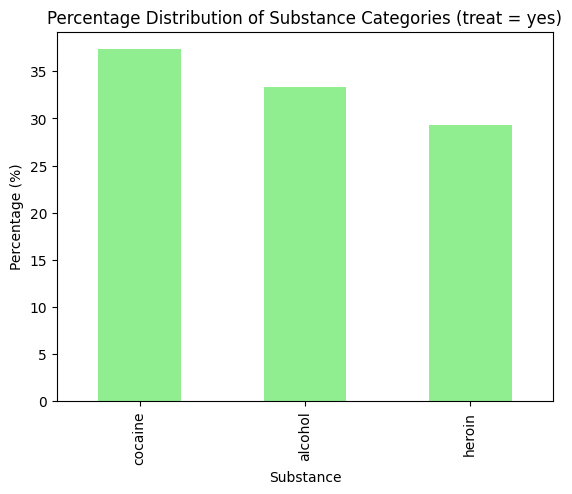

In [31]:
subset = dataset[dataset['treat'] == 'yes']
substance_counts = subset['substance'].value_counts()
substance_percent = subset['substance'].value_counts(normalize=True) * 100
print(substance_counts, end="\n\n")
print(substance_percent, end="\n\n")
substance_percent.plot(kind='bar', color='lightgreen')
plt.title('Percentage Distribution of Substance Categories (treat = yes)')
plt.xlabel('Substance')
plt.ylabel('Percentage (%)')
plt.show()


6

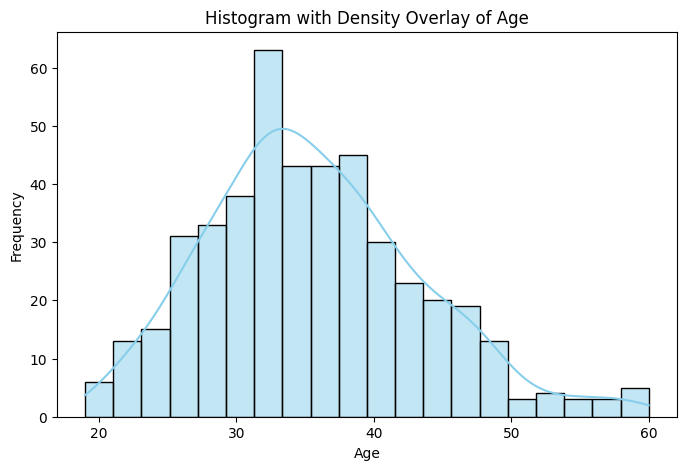

In [33]:
plt.figure(figsize=(8, 5))
sns.histplot(dataset['age'], kde=True, color='skyblue', bins=20)
plt.title('Histogram with Density Overlay of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

7

In [34]:
indtot = dataset['indtot'].dropna()

skewness = indtot.skew()
kurtosis = indtot.kurt()

print(f"Skewness of indtot: {skewness:.3f}")
print(f"Kurtosis of indtot: {kurtosis:.3f}")


Skewness of indtot: -1.501
Kurtosis of indtot: 2.796


8

In [39]:
# Simple Random Sampling
simple_random_sample = dataset.sample(n=30, random_state=42)

print("Simple Random Sampling:")
print(simple_random_sample[['id', 'pcs']].head())

# Systematic Sampling
N = len(dataset)
k = N // 30
random_start = np.random.randint(0, k)
systematic_indices = np.arange(random_start, N, k)
systematic_sample = dataset.iloc[systematic_indices]
print("\nSystematic Sampling:")
print(systematic_sample[['id', 'pcs']].head())

# Stratified Sampling
# Compute sample size for each stratum
stratified_sample = (
    dataset.groupby('female', group_keys=False)
           .apply(lambda x: x.sample(frac=30/len(dataset), random_state=42))
)

print("\nStratified Sampling (by female):")
print(stratified_sample[['female', 'pcs']].head())

# Cluster Sampling using 'racegrp' as cluster variable
num_clusters = 3
clusters = dataset['racegrp'].dropna().unique()
selected_clusters = np.random.choice(clusters, size=num_clusters, replace=False)
cluster_sample = dataset[dataset['racegrp'].isin(selected_clusters)]
print("\nCluster Sampling (by racegrp):")
print(cluster_sample[['racegrp', 'pcs']].head())



Simple Random Sampling:
      id        pcs
352  422  36.811359
39    44  71.392593
361  435  44.176655
358  431  54.523979
154  180  32.287056

Systematic Sampling:
    id        pcs
3    4  61.931679
18  20  37.452137
33  37  56.739849
48  54  45.483406
63  71  36.040157

Stratified Sampling (by female):
     female        pcs
140       0  29.785292
217       0  63.255444
368       0  45.584740
283       0  33.035706
421       0  63.863270

Cluster Sampling (by racegrp):
  racegrp        pcs
0   black  58.413689
1   white  36.036942
2   black  74.806328
3   white  61.931679
4   black  37.345585


C:\Users\varun\AppData\Local\Temp\ipykernel_20260\2463957367.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=30/len(dataset), random_state=42))


9

In [40]:
# Define a helper function for summary stats
def sample_stats(data, var):
    return pd.Series({
        'Mean': data[var].mean(),
        'Median': data[var].median(),
        'Mode': data[var].mode().iloc[0] if not data[var].mode().empty else np.nan,
        'Variance': data[var].var(),
        'Std Deviation': data[var].std()
    })

# Compute stats for each sampling method
stats_summary = pd.DataFrame({
    'Simple Random': sample_stats(simple_random_sample, 'pcs'),
    'Systematic': sample_stats(systematic_sample, 'pcs'),
    'Stratified': sample_stats(stratified_sample, 'pcs'),
    'Cluster': sample_stats(cluster_sample, 'pcs')
}).T

# Display neatly
print("Summary Statistics for PCS Across Sampling Methods")
print(stats_summary.round(3))


Summary Statistics for PCS Across Sampling Methods
                 Mean  Median    Mode  Variance  Std Deviation
Simple Random  46.874  48.224  14.074   171.347         13.090
Systematic     48.340  52.218  30.234   111.254         10.548
Stratified     47.534  46.396  27.270   113.112         10.635
Cluster        48.210  48.972  14.074   116.530         10.795


10 

The descriptive statistics of PCS across the four sampling methods show that all methods produce similar mean values (approximately 46–48), indicating reasonable consistency. Simple random sampling exhibits the highest variability, likely due to random inclusion of extreme values, while stratified sampling (by gender) is the most stable, maintaining representativeness and reducing variance. Systematic sampling shows slightly lower variability but may be biased if the dataset has periodic patterns. Cluster sampling, based on race groups, can introduce moderate bias if clusters are heterogeneous. Overall, stratified sampling provides the most reliable estimates, whereas simple random and cluster samples are more sensitive to variability.